# Process Raw Data

Have downloaded data for international football matches from Kaggle. Want to process the data. For example, add ELO scores for the two teams for each match, evaluated at the time of the match.

### Prerequisites

In [19]:
# Import packages
import pandas as pd
from tqdm import tqdm as tqdm
import json
import matplotlib.pyplot as plt

In [20]:
# Load data
results_df = pd.read_csv('Kaggle_Data/results.csv')
former_names_df = pd.read_csv('Kaggle_Data/former_names.csv')

results_df = results_df.dropna()

In [21]:
# Make all names current names in the results data
name_updates = {}
for _, row in former_names_df.iterrows():
    old_name = row['former']
    current_name = row['current']
    name_updates[old_name] = current_name

results_df = results_df.replace(name_updates)

results_df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49210,2026-03-31,Kosovo,Turkey,0.0,1.0,FIFA World Cup qualification,Pristina,Kosovo,False
49211,2026-03-31,Czech Republic,Denmark,2.0,2.0,FIFA World Cup qualification,Prague,Czech Republic,False
49212,2026-03-31,Cameroon,China PR,2.0,0.0,FIFA Series,Melbourne,Australia,True
49213,2026-03-31,Australia,Curaçao,5.0,1.0,FIFA Series,Melbourne,Australia,False


In [22]:
# Determine weights for the different competitions

# Get the competition names
competition_names = results_df['tournament'].unique().tolist()

# Initialise dict
weight_values = {}

# Initialise competition categories
competition_categories = {
    "tier 2": ["Olympic Games", "UEFA Euro", "African Cup of Nations"],
    "tier 3": ["FIFA World Cup qualification", "CONIFA World Football Cup qualification", "Copa América qualification", "African Cup of Nations qualification", "UEFA Euro qualification"]
}
count = 0
# Go through the competitions
for comp in competition_names:

    if comp == "FIFA World Cup":
        # World cup
        weight_values[comp] = 60
    elif comp in competition_categories['tier 2']:
        # Continental championship finals and major intercontinental tournaments
        weight_values[comp] = 50
    elif comp in competition_categories['tier 3']:
        # World cup and continental qualifiers and major tournaments
        weight_values[comp] = 40
    elif comp == 'Friendly':
        # Friendlies
        weight_values[comp] = 20
    else:
        # All other tournaments
        weight_values[comp] = 30
        # print(comp)
        count += 1

print(f"{count} tournaments not placed in higher category (not all should be, but should be checked)")
# print(json.dumps(weight_values, indent=4))

183 tournaments not placed in higher category (not all should be, but should be checked)


## Elo Ratings and Other Stats

Track the Elo ratings, and add columns to the data for the scores. The method of Elo calculation will match that from `eloratings.net`, including an additional 100 Elo score for the home team if the match is not played at a neutral ground.

Will also add a column for a moving average for the goals scored and conceeded by each team. Need to quantitatively justfify the alpha values.

In [23]:
# Get all the team names in the data
home_team_names = results_df['home_team'].unique().tolist()
away_team_names = results_df['away_team'].unique().tolist()
team_names = set(home_team_names + away_team_names)

# Initialise a record of their Elo ratings
elo_ratings = {t: {"Elo": 1500, "Num. Matches": 0, "Goals Scored EMA Short": 1.4, "Goals Conceeded EMA Short": 1.4, "Goals Scored EMA Long": 1.4, "Goals Conceeded EMA Long": 1.4} for t in team_names}
elo_ratings_convergence = {t: [1500] for t in team_names}   # For visualisations later
EMA_ALPHA_SHORT = 0.2
EMA_ALPHA_LONG = 0.1

# Initialise the results
home_elo = []
home_elo_num_matches = []   # Num. matches used to calculate Elo
home_goals_scored_ema_short = []
home_goals_conceeded_ema_short = []
home_goals_scored_ema_long = []
home_goals_conceeded_ema_long = []
away_elo = []
away_elo_num_matches = []
away_goals_scored_ema_short = []
away_goals_conceeded_ema_short = []
away_goals_scored_ema_long = []
away_goals_conceeded_ema_long = []

# Go through the data, and add Elo ratings
for _, row in tqdm(results_df.iterrows(), total=len(results_df)):

    # Get the two teams
    home_team = row['home_team']
    away_team = row['away_team']

    # Get their Elo ratings and num. matches
    elo_h = elo_ratings[home_team]['Elo']
    elo_n_h = elo_ratings[home_team]['Num. Matches']
    elo_a = elo_ratings[away_team]['Elo']
    elo_n_a = elo_ratings[away_team]['Num. Matches']

    # Add to the results
    home_elo.append(elo_h)
    home_elo_num_matches.append(elo_n_h)
    away_elo.append(elo_a)
    away_elo_num_matches.append(elo_n_a)


    ## Update Elo scores ##

    # Check if played at neutral ground
    neutral_ground = row['neutral']
    if not neutral_ground:
        updated_elo_h = elo_h + 100
    else:
        updated_elo_h = elo_h

    # Compute the expected result for each team
    er_home = 1 / (10**(-(updated_elo_h-elo_a)/400)+1)
    er_away = 1 - er_home

    # Determine the reuslt of the game
    home_goals = row['home_score']
    away_goals = row['away_score']
    if home_goals > away_goals:
        home_result = 1
        away_result = 0
    elif home_goals < away_goals:
        home_result = 0
        away_result = 1
    else:
        home_result = away_result = 0.5

    # Get the weighting factor
    tournament = row['tournament']
    weight = weight_values[tournament]

    # Update weight if score difference is large
    goal_diff = abs(home_goals - away_goals)
    if goal_diff >= 4:
        weight *= (1 + 3/4 + (goal_diff - 3)/8)
    elif goal_diff == 3:
        weight *= 1 + 3/4
    elif goal_diff == 2:
        weight *= 1 + 1/2

    # Update the respective Elo scores
    new_home_elo = elo_h + weight * (home_result - er_home)
    new_away_elo = elo_a + weight * (away_result - er_away)

    # Get goal EMAs
    home_scored_ema_short = elo_ratings[home_team]["Goals Scored EMA Short"]
    home_conceeded_ema_short = elo_ratings[home_team]["Goals Conceeded EMA Short"]
    away_scored_ema_short = elo_ratings[away_team]["Goals Scored EMA Short"]
    away_conceeded_ema_short = elo_ratings[away_team]["Goals Conceeded EMA Short"]

    home_scored_ema_long = elo_ratings[home_team]["Goals Scored EMA Long"]
    home_conceeded_ema_long = elo_ratings[home_team]["Goals Conceeded EMA Long"]
    away_scored_ema_long = elo_ratings[away_team]["Goals Scored EMA Long"]
    away_conceeded_ema_long = elo_ratings[away_team]["Goals Conceeded EMA Long"]

    # Add to the results
    home_goals_scored_ema_short.append(home_scored_ema_short)
    home_goals_conceeded_ema_short.append(home_conceeded_ema_short)
    away_goals_scored_ema_short.append(away_scored_ema_short)
    away_goals_conceeded_ema_short.append(away_conceeded_ema_short)

    home_goals_scored_ema_long.append(home_scored_ema_long)
    home_goals_conceeded_ema_long.append(home_conceeded_ema_long)
    away_goals_scored_ema_long.append(away_scored_ema_long)
    away_goals_conceeded_ema_long.append(away_conceeded_ema_long)

    # Update goal EMAs
    new_home_scored_ema_short = EMA_ALPHA_SHORT * home_goals + (1-EMA_ALPHA_SHORT) * home_scored_ema_short if home_scored_ema_short is not None else home_goals
    new_home_conceeded_ema_short = EMA_ALPHA_SHORT * away_goals + (1-EMA_ALPHA_SHORT) * home_conceeded_ema_short if home_conceeded_ema_short is not None else away_goals
    new_away_scored_ema_short = EMA_ALPHA_SHORT * away_goals + (1-EMA_ALPHA_SHORT) * away_scored_ema_short if away_scored_ema_short is not None else away_goals
    new_away_conceeded_ema_short = EMA_ALPHA_SHORT * home_goals + (1-EMA_ALPHA_SHORT) * away_conceeded_ema_short if away_conceeded_ema_short is not None else home_goals

    new_home_scored_ema_long = EMA_ALPHA_LONG * home_goals + (1-EMA_ALPHA_LONG) * home_scored_ema_long if home_scored_ema_long is not None else home_goals
    new_home_conceeded_ema_long = EMA_ALPHA_LONG * away_goals + (1-EMA_ALPHA_LONG) * home_conceeded_ema_long if home_conceeded_ema_long is not None else away_goals
    new_away_scored_ema_long = EMA_ALPHA_LONG * away_goals + (1-EMA_ALPHA_LONG) * away_scored_ema_long if away_scored_ema_long is not None else away_goals
    new_away_conceeded_ema_long = EMA_ALPHA_LONG * home_goals + (1-EMA_ALPHA_LONG) * away_conceeded_ema_long if away_conceeded_ema_long is not None else home_goals

    # Track new scores
    elo_ratings[home_team] = {"Elo": new_home_elo, "Num. Matches": elo_ratings[home_team]["Num. Matches"] + 1, "Goals Scored EMA Short": new_home_scored_ema_short, "Goals Conceeded EMA Short": new_home_conceeded_ema_short, "Goals Scored EMA Long": new_home_scored_ema_long, "Goals Conceeded EMA Long": new_home_conceeded_ema_long}
    elo_ratings[away_team] = {"Elo": new_away_elo, "Num. Matches": elo_ratings[away_team]["Num. Matches"] + 1, "Goals Scored EMA Short": new_away_scored_ema_short, "Goals Conceeded EMA Short": new_away_conceeded_ema_short, "Goals Scored EMA Long": new_away_scored_ema_long, "Goals Conceeded EMA Long": new_away_conceeded_ema_long}

    elo_ratings_convergence[home_team].append(new_home_elo)
    elo_ratings_convergence[away_team].append(new_away_elo)

    


# Add columns to dataframe
results_df['home_elo'] = home_elo
results_df['home_elo_num_matches'] = home_elo_num_matches
results_df['away_elo'] = away_elo
results_df['away_elo_num_matches'] = away_elo_num_matches
results_df['home_goals_scored_ema_short'] = home_goals_scored_ema_short
results_df['home_goals_conceeded_ema_short'] = home_goals_conceeded_ema_short
results_df['away_goals_scored_ema_short'] = away_goals_scored_ema_short
results_df['away_goals_conceeded_ema_short'] = away_goals_conceeded_ema_short
results_df['home_goals_scored_ema_long'] = home_goals_scored_ema_long
results_df['home_goals_conceeded_ema_long'] = home_goals_conceeded_ema_long
results_df['away_goals_scored_ema_long'] = away_goals_scored_ema_long
results_df['away_goals_conceeded_ema_long'] = away_goals_conceeded_ema_long

# Save the dataframe
results_df.to_csv('results_with_stats.csv')

  0%|          | 0/49215 [00:00<?, ?it/s]

100%|██████████| 49215/49215 [00:01<00:00, 40615.65it/s]


### Plot Convergence

The description on `eloratings.net` states that the Elo ratings usually converge to an accurate measure of a teams strength after around 30 matches. Therefore, I wish to plot the change in a teams Elo rating as they play more matches.

Naturally, this will be competing with real changes in a team's strength, however the convergence should still be visible.

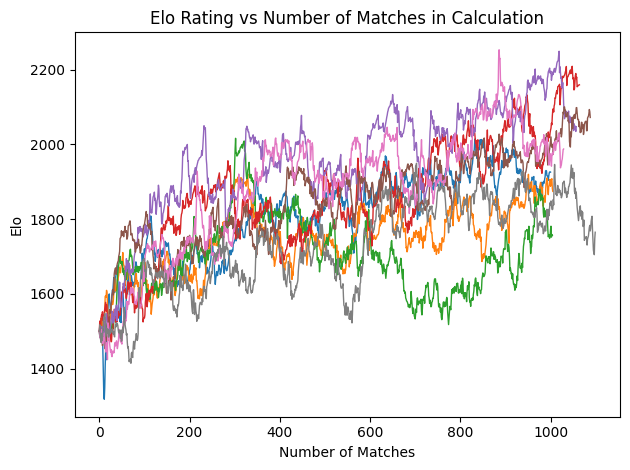

In [24]:
minimum_matches = 1000    # Minimum number of matches to include team on the figure

fig = plt.Figure((10,5))

# Go through the teams
for team, elo_history in elo_ratings_convergence.items():

    if len(elo_history) < minimum_matches:
        continue 

    plt.plot(range(len(elo_history)),
             elo_history,
             label=team,
             linewidth=1)
    

plt.ylabel("Elo")
plt.xlabel("Number of Matches")
plt.title("Elo Rating vs Number of Matches in Calculation")
# plt.legend(loc=0)
plt.tight_layout()
plt.show()


In the above chart, the quick rise in Elo score over the first ~200 matches is clearly visible, after which the scores change in a manner that could be easily explained with changes in a teams actual strength. Therefore, 200-300 matches is a very conservative estimate for how long it takes for Elo scores to equilibriate. However, the quoted 30 matches specifies it is for convergence in **relative** strength compared with other teams, which is the more important quality.

The chart only includes teams with over 1000 natches in the data. These will naturally be footballing nations, hence they all have high Elo scores.